In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')

In [16]:
data.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [19]:
print(data.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')


In [20]:
data.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [21]:
total_sales = data['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 2261536.7827


In [22]:
region_sales = data.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


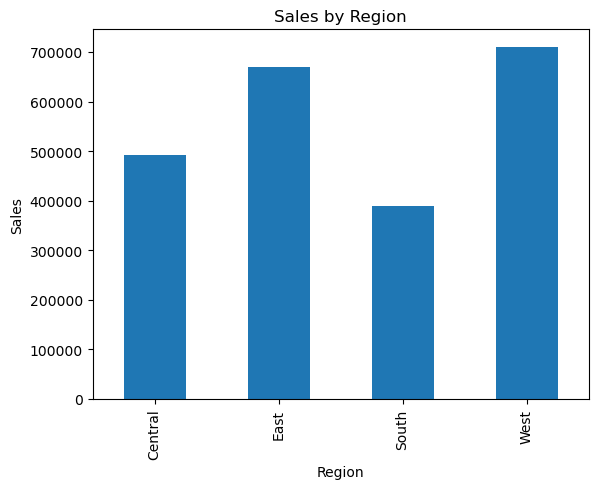

In [23]:
region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.ylabel("Sales")

plt.show()

In [24]:
category_sales = data.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


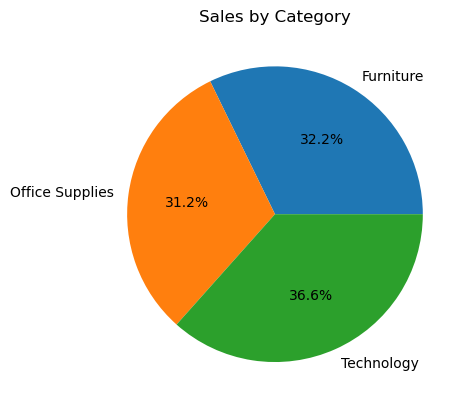

In [25]:
category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales by Category")

plt.ylabel("")

plt.show()

In [26]:
top_products = data.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


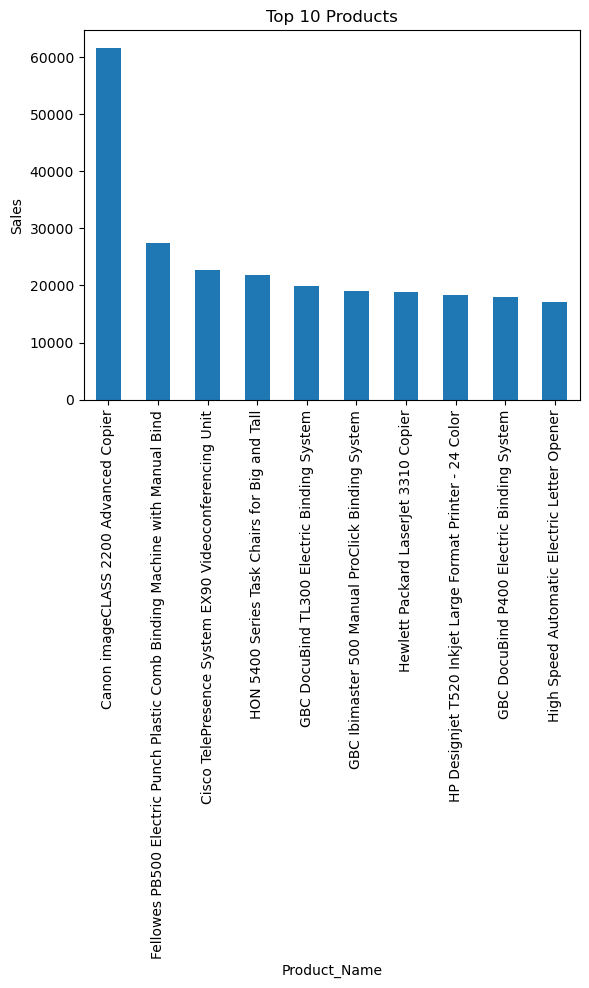

In [27]:
top_products.plot(kind='bar')

plt.title("Top 10 Products")

plt.ylabel("Sales")

plt.show()

In [29]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True, errors='coerce')

data['Month'] = data['Order_Date'].dt.month

monthly_sales = data.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


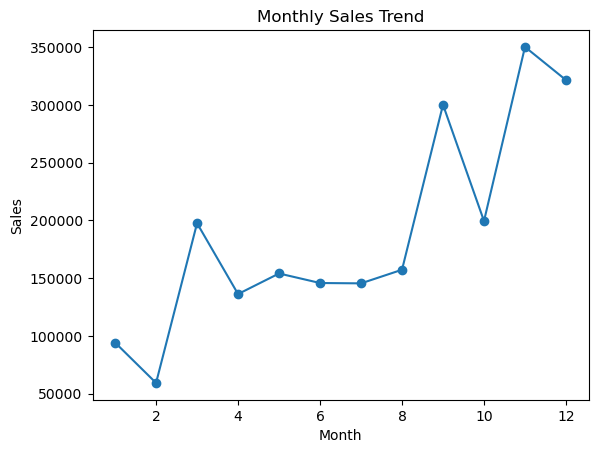

In [30]:
monthly_sales.plot(kind='line', marker='o')

import matplotlib.pyplot as plt

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [32]:
data['Estimated_Profit'] = data['Sales'] * 0.20

print("Total Estimated Profit:", data['Estimated_Profit'].sum())

Total Estimated Profit: 452307.35654000007


In [33]:
profit_region = data.groupby('Region')['Estimated_Profit'].sum()

print(profit_region)

Region
Central     98529.38264
East       133903.74520
South       77830.29180
West       142043.93690
Name: Estimated_Profit, dtype: float64


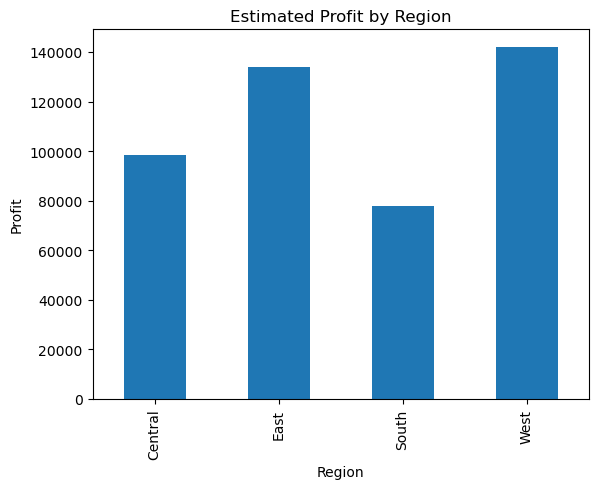

In [34]:
profit_region.plot(kind='bar')

plt.title("Estimated Profit by Region")

plt.ylabel("Profit")

plt.show()